# Обучение YOLO-модели на RGB и RGB + Depth данных 

Сравниваются два варианта обучающего набора для распознавания элементов интерьера: лестницы (`ladder`), стены (`wall`) и углы (`corner`).
Первый вариант — только RGB-изображения (baseline). Второй расширяет набор изображениями глубины (depth), полученными из самих RGB-кадров (оценка глубины по одному изображению), то есть синтетическими.

## Гипотезы
**H0:** Добавление изображений глубины, полученных из RGB-кадров, не приводит к улучшению качества детекции стен, углов и препятствий по сравнению с обучением только на RGB-изображениях.

**H1:** Добавление изображений глубины, полученных из RGB-кадров, повышает качество детекции за счёт дополнительного представления геометрии сцены, формы объектов и относительного расстояния до элементов окружающей среды.



## 1. Подключение Google Drive и установка библиотек

In [ ]:
# Импорты
from google.colab import drive
import os, json, random, shutil, hashlib
from pathlib import Path
from collections import Counter

import yaml
import numpy as np
import cv2
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ttest_rel


In [ ]:
drive.mount('/content/drive')
!pip -q install ultralytics


Mounted at /content/drive
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 60.5 MB/s eta 0:00:00


In [ ]:
# Единая конфигурация проекта
BASE = '/content/drive/MyDrive/dataset_cv'
CLASS_NAMES = ['ladder', 'wall', 'corner']
NAMES = {i: n for i, n in enumerate(CLASS_NAMES)}
SEED = 42
random.seed(SEED); np.random.seed(SEED)
print('Классы:', NAMES)


Классы: {0: 'ladder', 1: 'wall', 2: 'corner'}


## 2. Проверка структуры папки проекта

In [ ]:
print(os.listdir(BASE))

['classes.txt', 'images', 'labels', 'YOLOdataset', 'runs', 'wall and corners rgb', 'wall and corners label', 'wall and corners depth', 'wall and corners depth labels', 'wall and corners labels rgb_depth', 'split_map.json', 'data.yaml', 'YOLOdataset_rgb_depth', 'data_rgb_depth.yaml']


## 3. Формирование baseline-датасета только из RGB-изображений

Разбиение 70/20/10 на train/valid/test. Дополнительно сохраняется карта `split_map.json` (сцена → часть): она нужна, чтобы depth-кадры той же сцены попали в ту же часть и не возникло утечки данных между train и test.


In [ ]:
sourcei = f'{BASE}/images/rgb'
sourcel = f'{BASE}/labels'
dataset = f'{BASE}/YOLOdataset'

for sp in ['train', 'valid', 'test']:
    os.makedirs(f'{dataset}/{sp}/images', exist_ok=True)
    os.makedirs(f'{dataset}/{sp}/labels', exist_ok=True)

allimages = [f for f in os.listdir(sourcei)
             if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
random.seed(SEED)
random.shuffle(allimages)

n_train = int(len(allimages) * 0.7)
n_valid = int(len(allimages) * 0.2)

split_assign = {}
for idx, img in enumerate(allimages):
    sp = 'train' if idx < n_train else ('valid' if idx < n_train + n_valid else 'test')
    split_assign[img] = sp

split_map = {img.rsplit('.', 1)[0]: sp for img, sp in split_assign.items()}
with open(f'{BASE}/split_map.json', 'w') as f:
    json.dump(split_map, f)

def copy_pair(img, sp, src_img_dir, src_lbl_dir, dst_root, prefix=''):
    shutil.copy(f'{src_img_dir}/{img}', f'{dst_root}/{sp}/images/{prefix}{img}')
    txt = img.rsplit('.', 1)[0] + '.txt'
    src_lbl = f'{src_lbl_dir}/{txt}'
    if os.path.exists(src_lbl):
        shutil.copy(src_lbl, f'{dst_root}/{sp}/labels/{prefix}{txt}')
    else:
        print(f'Нет разметки для файла: {img}')

for img, sp in split_assign.items():
    copy_pair(img, sp, sourcei, sourcel, dataset)

for sp in ['train', 'valid', 'test']:
    print(f'{sp}: {sum(1 for v in split_assign.values() if v == sp)} изображений')


train: 242 изображений
valid: 69 изображений
test: 36 изображений


## 4. Создание `data.yaml` для RGB-датасета

In [ ]:
data_yaml = f'{BASE}/data.yaml'
data = {
    'train': f'{dataset}/train/images',
    'val':   f'{dataset}/valid/images',
    'test':  f'{dataset}/test/images',
    'nc': len(CLASS_NAMES),
    'names': CLASS_NAMES,
}
with open(data_yaml, 'w') as f:
    yaml.dump(data, f, default_flow_style=False)
print('Создан:', data_yaml)


Создан: /content/drive/MyDrive/dataset_cv/data.yaml


## 5. Проверка баланса классов

Подсчёт числа объектов каждого класса. Важно держать в голове абсолютные числа: при малом количестве экземпляров `wall` и особенно `corner` метрики по ним нестабильны.


ladder: 151
wall: 137
corner: 108


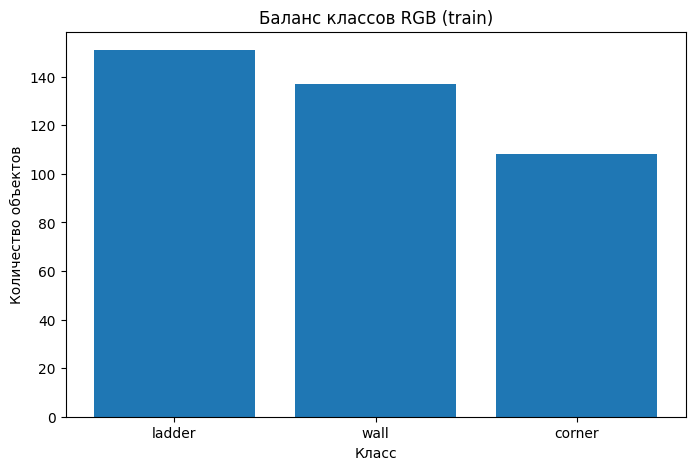

Counter({0: 151, 1: 137, 2: 108})

In [ ]:
def class_balance(labels_dir, title):
    c = Counter()
    for lf in Path(labels_dir).glob('*.txt'):
        for line in open(lf):
            if line.strip():
                c[int(line.split()[0])] += 1
    for cid in sorted(c):
        print(f'{NAMES[cid]}: {c[cid]}')
    classes = [NAMES[i] for i in sorted(c)]
    counts = [c[i] for i in sorted(c)]
    plt.figure(figsize=(8, 5)); plt.bar(classes, counts)
    plt.title(title); plt.xlabel('Класс'); plt.ylabel('Количество объектов'); plt.show()
    return c

class_balance(f'{dataset}/train/labels', 'Баланс классов RGB (train)')


## 5b. Камеро-имитирующие аугментации

Фотометрические преобразования, имитирующие разные камеры: изменение экспозиции/гаммы, баланса белого, сенсорный шум, размытие оптики, JPEG-артефакты, понижение разрешения (как у веб-камеры) и CLAHE для малоконтрастных стен. Преобразования не двигают объекты, поэтому разметка просто копируется.


In [ ]:
APPLY_CAMERA_AUG = False
N_AUG = 2

def _gamma(img, g):
    table = ((np.arange(256) / 255.0) ** (1.0 / g) * 255).astype(np.uint8)
    return cv2.LUT(img, table)

def _white_balance(img, gain):
    out = img.astype(np.float32)
    out[..., 0] *= gain[0]; out[..., 2] *= gain[1]
    return np.clip(out, 0, 255).astype(np.uint8)

def _jpeg(img, q):
    ok, enc = cv2.imencode('.jpg', img, [int(cv2.IMWRITE_JPEG_QUALITY), q])
    return cv2.imdecode(enc, cv2.IMREAD_COLOR) if ok else img

def _downscale(img, f):
    h, w = img.shape[:2]
    small = cv2.resize(img, (max(1, int(w*f)), max(1, int(h*f))), interpolation=cv2.INTER_AREA)
    return cv2.resize(small, (w, h), interpolation=cv2.INTER_LINEAR)

def _clahe(img):
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    l = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8)).apply(l)
    return cv2.cvtColor(cv2.merge((l, a, b)), cv2.COLOR_LAB2BGR)

def camera_sim(img, rng):
    if rng.random() < 0.7:                       # экспозиция / контраст
        img = cv2.convertScaleAbs(img, alpha=rng.uniform(0.7, 1.3), beta=rng.uniform(-30, 30))
    if rng.random() < 0.5:                       # гамма
        img = _gamma(img, rng.uniform(0.7, 1.5))
    if rng.random() < 0.5:                        # баланс белого / температура
        img = _white_balance(img, (rng.uniform(0.85, 1.15), rng.uniform(0.85, 1.15)))
    if rng.random() < 0.5:                        # сенсорный шум
        noise = rng.normal(0, rng.uniform(5, 20), img.shape)
        img = np.clip(img.astype(np.float32) + noise, 0, 255).astype(np.uint8)
    if rng.random() < 0.4:                        # размытие оптики
        k = int(rng.choice([3, 5, 7])); img = cv2.GaussianBlur(img, (k, k), 0)
    if rng.random() < 0.5:                        # JPEG / ISP
        img = _jpeg(img, int(rng.uniform(30, 70)))
    if rng.random() < 0.3:                        # разрешение веб-камеры
        img = _downscale(img, rng.uniform(0.5, 0.9))
    if rng.random() < 0.3:                        # CLAHE для малоконтрастных стен
        img = _clahe(img)
    return img

def augment_train(dataset_root, n_aug=N_AUG):
    img_dir = Path(dataset_root) / 'train' / 'images'
    lbl_dir = Path(dataset_root) / 'train' / 'labels'
    # чистим прошлые аугментации
    for p in list(img_dir.glob('*_aug*')) + list(lbl_dir.glob('*_aug*')):
        p.unlink()
    rng = np.random.default_rng(SEED)
    originals = [p for p in img_dir.glob('*')
                 if p.suffix.lower() in ('.jpg', '.jpeg', '.png') and '_aug' not in p.stem]
    made = 0
    for ip in originals:
        img = cv2.imread(str(ip))
        if img is None:
            continue
        lp = lbl_dir / (ip.stem + '.txt')
        for k in range(n_aug):
            cv2.imwrite(str(img_dir / f'{ip.stem}_aug{k}{ip.suffix}'), camera_sim(img, rng))
            if lp.exists():
                shutil.copy(lp, lbl_dir / f'{ip.stem}_aug{k}.txt')
            made += 1
    print(f'{dataset_root}: создано аугментированных кадров: {made}')

if APPLY_CAMERA_AUG:
    augment_train(dataset)
else:
    print('Камеро-аугментации выключены (APPLY_CAMERA_AUG=False)')


Камеро-аугментации выключены (APPLY_CAMERA_AUG=False)


## 6. Обучение baseline-модели на RGB-датасете

Определяем единую функцию `train_one` (её же используем для RGB+Depth и для статистики — это гарантирует одинаковые условия).


In [ ]:
from ultralytics import YOLO

MODEL_WEIGHTS = 'yolov8s.pt'   # крупнее nano: лучше работает при малых данных
TRAIN_EPOCHS = 150

def train_one(data_yaml, name, weights=MODEL_WEIGHTS, epochs=TRAIN_EPOCHS, seed=SEED):
    model = YOLO(weights)
    model.train(
        data=data_yaml, epochs=epochs, patience=50, imgsz=800, batch=-1,
        cos_lr=True, seed=seed, deterministic=True,
        # реальные аугментации
        hsv_h=0.015, hsv_s=0.7, hsv_v=0.6,        # var яркости -> устойчивость к освещению
        degrees=7.0, translate=0.1, scale=0.5,
        fliplr=0.5, flipud=0.0,                    # вертикальный флип не нужен (пол/потолок)
        mosaic=1.0, close_mosaic=15, mixup=0.1,
        project=f'{BASE}/runs', name=name, plots=True, exist_ok=True,
    )
    return model

print('Обучение baseline (RGB)...')
model_rgb = train_one(data_yaml, 'train_rgb_baseline')
print('Готово.')


Обучение baseline (RGB)...
Ultralytics 8.4.58 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=-1, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=15, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/drive/MyDrive/dataset_cv/data.yaml, degrees=7.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.6, imgsz=800, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train_rgb_baseline, nbs=64, nms=False, opset=None

### Оценка baseline (per-class + confusion matrix)

`evaluate` печатает общий mAP и отдельно AP по каждому классу — именно так видно качество по `wall` и `corner`. Файл `confusion_matrix.png` сохраняется в папке прогона val: по нему смотри путаницу `wall`↔`corner`.


In [ ]:
def evaluate(model, data_yaml, split='test'):
    m = model.val(data=data_yaml, split=split, plots=True)
    print(f'\n[{split}] mAP50={m.box.map50:.3f}  mAP50-95={m.box.map:.3f}')
    print(f'{"класс":8s}  {"AP50":>6s}  {"AP50-95":>8s}')
    for i, c in enumerate(m.box.ap_class_index):
        print(f'{NAMES[int(c)]:8s}  {m.box.ap50[i]:6.3f}  {m.box.ap[i]:8.3f}')
    return m

m_rgb = evaluate(model_rgb, data_yaml)


Ultralytics 8.4.58 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
Model summary (fused): 73 layers, 11,126,745 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.4±0.1 ms, read: 5.2±4.8 MB/s, size: 14.9 KB)
val: Scanning /content/drive/MyDrive/dataset_cv/YOLOdataset/test/labels.cache... 97 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 97/97 31.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 2.3s/it 16.2s
                   all         97        111      0.773      0.805      0.736      0.462
                ladder         51         52      0.888      0.865      0.831      0.597
                  wall         34         37      0.741      0.838      0.737      0.517
                corner         21         22      0.691      0.711       0.64      0.271
Speed: 3.9ms preprocess, 3.2ms inference, 0.0ms loss, 2.2ms postprocess per image
Results saved to /cont

In [ ]:
# Контроль распределения объектов по частям RGB-датасета
for split in ['train', 'valid', 'test']:
    c = Counter()
    for txt in Path(f'{dataset}/{split}/labels').glob('*.txt'):
        for line in txt.read_text().strip().splitlines():
            if line.strip():
                c[NAMES[int(line.split()[0])]] += 1
    print(split, dict(c))


train {'ladder': 151, 'wall': 137, 'corner': 108}
valid {'wall': 58, 'corner': 54, 'ladder': 70}
test {'corner': 22, 'ladder': 52, 'wall': 37}


## 7. Формирование экспериментального датасета RGB + Depth

Сначала копируются все RGB-кадры с сохранением их split. Затем добавляются depth-кадры, причём каждый depth кладётся в **ту же часть**, что и его RGB-сцена (по `split_map`). Это устраняет утечку, когда одна сцена была в train (RGB) и в test (depth) одновременно. Для depth-сцен, которых нет среди RGB, используется стабильное разбиение.


In [ ]:
rgb_dataset = f'{BASE}/YOLOdataset'
depth_folder = f'{BASE}/images/depth'
labels_folder = f'{BASE}/labels'
new_dataset = f'{BASE}/YOLOdataset_rgb_depth'

if os.path.exists(new_dataset):
    shutil.rmtree(new_dataset)
for sp in ['train', 'valid', 'test']:
    os.makedirs(f'{new_dataset}/{sp}/images', exist_ok=True)
    os.makedirs(f'{new_dataset}/{sp}/labels', exist_ok=True)

# 1) RGB копируем как есть, сохраняя их split
for sp in ['train', 'valid', 'test']:
    for img in os.listdir(f'{rgb_dataset}/{sp}/images'):
        if img.lower().endswith(('.jpg', '.jpeg', '.png')) and '_aug' not in img:
            stem = img.rsplit('.', 1)[0]
            shutil.copy(f'{rgb_dataset}/{sp}/images/{img}',
                        f'{new_dataset}/{sp}/images/rgb_{img}')
            lp = f'{rgb_dataset}/{sp}/labels/{stem}.txt'
            if os.path.exists(lp):
                shutil.copy(lp, f'{new_dataset}/{sp}/labels/rgb_{stem}.txt')

# 2) depth -> в ту же часть, что и RGB-сцена (без утечки)
split_map = json.load(open(f'{BASE}/split_map.json'))

def stable_split(stem):
    h = int(hashlib.md5(stem.encode()).hexdigest(), 16) % 100
    return 'train' if h < 70 else ('valid' if h < 90 else 'test')

depth_images = [f for f in os.listdir(depth_folder)
                if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

counts, no_label = Counter(), 0
for img in depth_images:
    stem = img.rsplit('.', 1)[0]
    sp = split_map.get(stem, stable_split(stem))
    counts[sp] += 1
    shutil.copy(f'{depth_folder}/{img}', f'{new_dataset}/{sp}/images/depth_{img}')
    lp = f'{labels_folder}/{stem}.txt'
    if os.path.exists(lp):
        shutil.copy(lp, f'{new_dataset}/{sp}/labels/depth_{stem}.txt')
    else:
        open(f'{new_dataset}/{sp}/labels/depth_{stem}.txt', 'w').close()
        no_label += 1

data_yaml_d = f'{BASE}/data_rgb_depth.yaml'
yaml.dump({'train': f'{new_dataset}/train/images',
           'val':   f'{new_dataset}/valid/images',
           'test':  f'{new_dataset}/test/images',
           'nc': len(CLASS_NAMES), 'names': CLASS_NAMES},
          open(data_yaml_d, 'w'), default_flow_style=False)

print('RGB+Depth датасет создан. Depth по частям:', dict(counts))
print('Depth-кадров без разметки (пустой label):', no_label)

if APPLY_CAMERA_AUG:
    augment_train(new_dataset)


RGB+Depth датасет создан. Depth по частям: {'train': 256, 'valid': 63, 'test': 28}
Depth-кадров без разметки (пустой label): 0


## 8. Проверка баланса классов (RGB + Depth)

ladder: 263
wall: 225
corner: 180


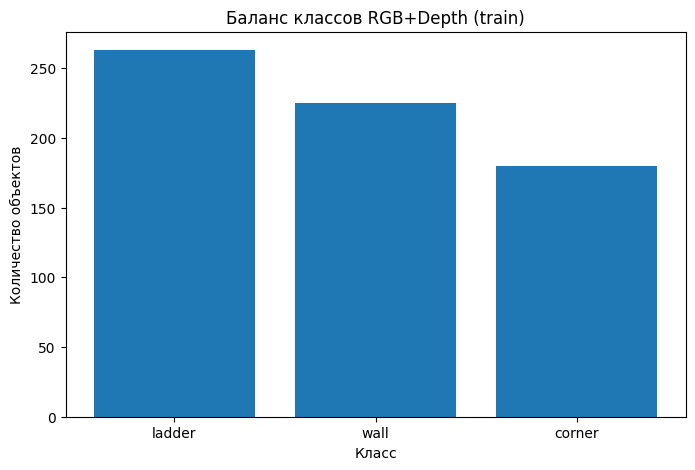

Counter({2: 180, 0: 263, 1: 225})

In [ ]:
class_balance(f'{new_dataset}/train/labels', 'Баланс классов RGB+Depth (train)')

## 9. Обучение модели на RGB + Depth

Та же функция `train_one` с тем же `seed` и гиперпараметрами — чтобы сравнение с baseline было честным и различия не объяснялись разными настройками обучения.


In [ ]:
print('Обучение RGB+Depth...')
model_rgbd = train_one(data_yaml_d, 'train_rgb_depth')
m_rgbd = evaluate(model_rgbd, data_yaml_d)


Обучение RGB+Depth...
Ultralytics 8.4.58 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=-1, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=15, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/drive/MyDrive/dataset_cv/data_rgb_depth.yaml, degrees=7.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.6, imgsz=800, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train_rgb_depth, nbs=64, nms=False, opset=No

## 10. Сравнение моделей и вывод по гипотезам

**Результаты (тест):**

| Метрика | RGB | RGB+Depth | Δ (Depth−RGB) |
|---|---|---|---|
| ladder (AP50-95) | 0.597 | 0.513 | −0.084 |
| wall (AP50-95) | 0.517 | 0.506 | −0.012 |
| corner (AP50-95) | 0.271 | 0.173 | −0.098 |
| **ALL mAP50** | **0.736** | **0.635** | **−0.101** |
| **ALL mAP50-95** | **0.462** | **0.397** | **−0.065** |

**Вывод по гипотезам.** Добавление синтетических depth-кадров ухудшило качество по **всем** классам и по обоим общим показателям: mAP50 упал на 0.101, mAP50-95 — на 0.065. Сильнее всего пострадал `corner` (AP50-95 0.271 → 0.173). Прироста, заявленного в H1, не наблюдается — наоборот, метрики снизились. Следовательно, по имеющимся данным **принимается H0**.

**Почему так.** depth-кадры здесь синтетические и стилистически отличаются от настоящих фотографий. Подаваемые в тот же одно­поточный детектор, они образуют второй визуальный домен, который модель вынуждена описывать теми же весами. В результате depth не добавляет полезную геометрию, а снижает распределение RGB-признаков и разделимость классов — особенно для тонкого и малочисленного класса `corner`.


In [ ]:
def per_class_map(m):
    d = {NAMES[int(c)]: float(m.box.ap[i]) for i, c in enumerate(m.box.ap_class_index)}
    d['ALL_mAP50']    = float(m.box.map50)
    d['ALL_mAP50-95'] = float(m.box.map)
    return d

cmp = pd.DataFrame({'RGB': per_class_map(m_rgb), 'RGB+Depth': per_class_map(m_rgbd)})
cmp['Δ (Depth−RGB)'] = cmp['RGB+Depth'] - cmp['RGB']
print(cmp.round(3))


                RGB  RGB+Depth  Δ (Depth−RGB)
ladder        0.597      0.513         -0.084
wall          0.517      0.506         -0.012
corner        0.271      0.173         -0.098
ALL_mAP50     0.736      0.635         -0.101
ALL_mAP50-95  0.462      0.397         -0.065


## 11. Итоговый вывод

1. **Базовое качество (RGB).** Общий mAP50 = 0.736, mAP50-95 = 0.462. По классам (AP50-95): `ladder` 0.597, `wall` 0.517, `corner` 0.271. Самый слабый класс — `corner`, что ожидаемо: угол — это тонкая геометрическая структура (линия пересечения плоскостей), а не компактный объект, и его сложно описать прямоугольной рамкой. Переобучения нет: валидационные метрики выходили на плато к концу обучения и не снижались.

2. **Эффект depth.** Добавление синтетических depth-кадров **ухудшило** качество по всем метрикам: ΔmAP50 = −0.101, ΔmAP50-95 = −0.065; по классам ΔAP50-95: `ladder` −0.084, `wall` −0.012, `corner` −0.098.

3. **Проверка гипотез.** По данным эксперимента принимается **H0**.


